# 📊 Notebook 01 — Exploratory Data Analysis (EDA)

**CO543/CO5430 — Traffic Sign Detection**

**Goals of this notebook:**
- Verify dataset integrity (image count, annotation count)
- Plot class distribution histogram
- Plot sign bounding-box size distribution
- Visualise sample images per class
- Identify class imbalance and small-sign challenges

> ⚠️ Run `src/data/convert_gtsdb.py` first to generate `data/processed/gtsdb/` before running this notebook.

## 0. Imports & Configuration

In [15]:
import os
import sys
from pathlib import Path
from collections import Counter

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Add project root to path
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))

# ── Paths ──────────────────────────────────────────────────────────────
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed' / 'gtsdb'
TRAIN_DIR     = PROCESSED_DIR / 'train'
VAL_DIR       = PROCESSED_DIR / 'val'
TEST_DIR      = PROCESSED_DIR / 'test'

# ── Class names (3 super-classes) ─────────────────────────────────────
CLASS_NAMES = {0: 'Prohibitory', 1: 'Danger', 2: 'Mandatory'}
CLASS_COLOURS = {0: '#e74c3c', 1: '#f39c12', 2: '#2980b9'}

print(f'Project root : {PROJECT_ROOT}')
print(f'Processed dir: {PROCESSED_DIR}')
print(f'Train dir exists: {TRAIN_DIR.exists()}')

Project root : E:\traffic-sign-detection
Processed dir: E:\traffic-sign-detection\data\processed\gtsdb
Train dir exists: True


## 1. Dataset Integrity Check

In [16]:
def count_split(split_dir: Path):
    """Return (n_images, n_labels, n_annotations) for a split directory."""
    img_dir = split_dir / 'images'
    lbl_dir = split_dir / 'labels'
    if not img_dir.exists():
        return 0, 0, 0
    imgs = list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))
    lbls = list(lbl_dir.glob('*.txt')) if lbl_dir.exists() else []
    n_annotations = sum(len(open(l).readlines()) for l in lbls)
    return len(imgs), len(lbls), n_annotations

for name, d in [('Train', TRAIN_DIR), ('Val', VAL_DIR), ('Test', TEST_DIR)]:
    n_img, n_lbl, n_ann = count_split(d)
    print(f'{name:5s} → images: {n_img:4d} | label files: {n_lbl:4d} | annotations: {n_ann:5d}')

Train → images:  365 | label files:  365 | annotations:   527
Val   → images:   80 | label files:   80 | annotations:   110
Test  → images:   81 | label files:   81 | annotations:   110


## 2. Class Distribution

In [17]:
def load_all_annotations(split_dirs: list[Path]) -> pd.DataFrame:
    """Load all YOLO annotations from multiple splits into a DataFrame."""
    records = []
    for split_dir in split_dirs:
        lbl_dir = split_dir / 'labels'
        if not lbl_dir.exists():
            continue
        split_name = split_dir.name
        for lbl_path in lbl_dir.glob('*.txt'):
            img_path = split_dir / 'images' / (lbl_path.stem + '.jpg')
            img = cv2.imread(str(img_path))
            h, w = (img.shape[:2] if img is not None else (640, 640))
            with open(lbl_path) as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) == 5:
                        cls, xc, yc, bw, bh = map(float, parts)
                        records.append({
                            'split': split_name,
                            'image': lbl_path.stem,
                            'class_id': int(cls),
                            'class_name': CLASS_NAMES.get(int(cls), 'unknown'),
                            'x_center': xc, 'y_center': yc,
                            'width': bw,  'height': bh,
                            'width_px': bw * w, 'height_px': bh * h,
                            'area_px': bw * w * bh * h
                        })
    return pd.DataFrame(records)

df = load_all_annotations([TRAIN_DIR, VAL_DIR, TEST_DIR])
print(f'Total annotations: {len(df)}')
print(df.groupby(['split', 'class_name']).size().unstack(fill_value=0))

Total annotations: 747
class_name  Danger  Mandatory  Prohibitory
split                                     
test            49         14           47
train          228         87          212
val             49         19           42


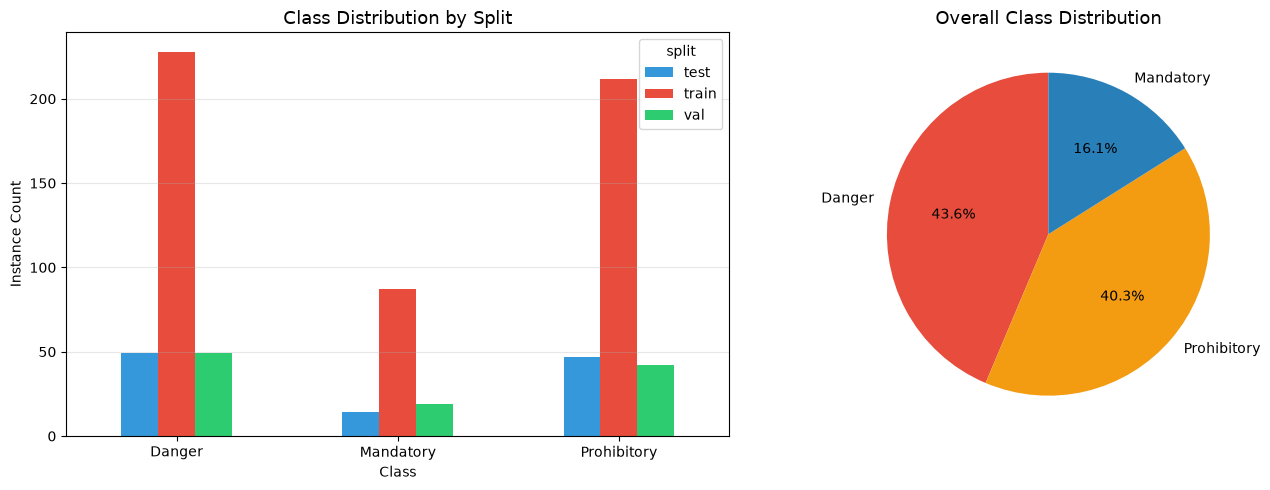

Saved → E:\traffic-sign-detection\results\figures\class_distribution.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: per-split class distribution bar chart ──
pivot = df.groupby(['class_name', 'split']).size().unstack(fill_value=0)
pivot.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c', '#2ecc71'])
axes[0].set_title('Class Distribution by Split', fontsize=13)
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Instance Count')
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', alpha=0.3)

# ── Right: overall pie chart ──
total_by_class = df['class_name'].value_counts()
axes[1].pie(
    total_by_class.values,
    labels=total_by_class.index,
    autopct='%1.1f%%',
    colors=[CLASS_COLOURS[k] for k in sorted(CLASS_NAMES)],
    startangle=90
)
axes[1].set_title('Overall Class Distribution', fontsize=13)

plt.tight_layout()
out = PROJECT_ROOT / 'results' / 'figures' / 'class_distribution.png'
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150)
plt.show()
print(f'Saved → {out}')

## 3. Bounding Box Size Distribution

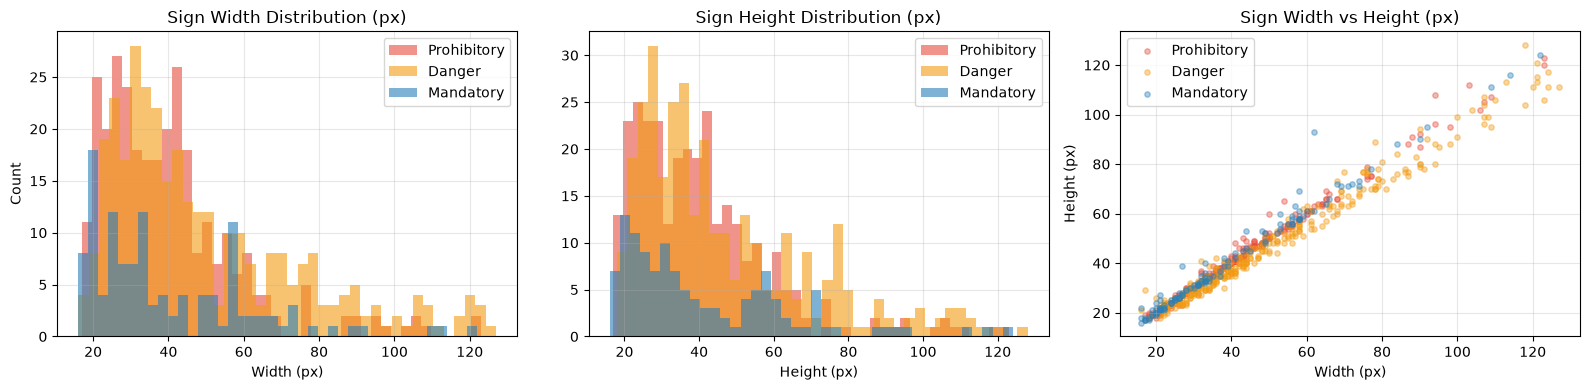

Saved → E:\traffic-sign-detection\results\figures\bbox_size_distribution.png

Bounding box size summary (pixels):
            width_px                                            height_px  \
               count  mean   std   min   25%   50%   75%    max     count   
class_name                                                                  
Danger         326.0  49.5  25.4  16.0  31.0  41.0  62.8  127.0     326.0   
Mandatory      120.0  39.9  21.8  16.0  23.5  33.0  55.2  122.0     120.0   
Prohibitory    301.0  40.2  18.6  17.0  26.0  37.0  48.0  123.0     301.0   

                   ...              area_px                                \
             mean  ...   75%    max   count    mean     std    min    25%   
class_name         ...                                                      
Danger       47.0  ...  60.0  128.0   326.0  2918.1  3125.9  324.0  900.0   
Mandatory    41.4  ...  56.0  124.0   120.0  2135.2  2548.1  256.0  573.7   
Prohibitory  40.6  ...  48.0  123.0   

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Width distribution
for cls_id, name in CLASS_NAMES.items():
    subset = df[df['class_id'] == cls_id]
    axes[0].hist(subset['width_px'], bins=40, alpha=0.6, label=name, color=CLASS_COLOURS[cls_id])
axes[0].set_title('Sign Width Distribution (px)')
axes[0].set_xlabel('Width (px)'); axes[0].set_ylabel('Count')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Height distribution
for cls_id, name in CLASS_NAMES.items():
    subset = df[df['class_id'] == cls_id]
    axes[1].hist(subset['height_px'], bins=40, alpha=0.6, label=name, color=CLASS_COLOURS[cls_id])
axes[1].set_title('Sign Height Distribution (px)')
axes[1].set_xlabel('Height (px)'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Area scatter
for cls_id, name in CLASS_NAMES.items():
    subset = df[df['class_id'] == cls_id]
    axes[2].scatter(subset['width_px'], subset['height_px'],
                    alpha=0.4, s=15, label=name, color=CLASS_COLOURS[cls_id])
axes[2].set_title('Sign Width vs Height (px)')
axes[2].set_xlabel('Width (px)'); axes[2].set_ylabel('Height (px)')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
out = PROJECT_ROOT / 'results' / 'figures' / 'bbox_size_distribution.png'
plt.savefig(out, dpi=150)
plt.show()
print(f'Saved → {out}')

# Summary stats
print('\nBounding box size summary (pixels):')
print(df[['class_name','width_px','height_px','area_px']].groupby('class_name').describe().round(1))

## 4. Sample Image Grid per Class

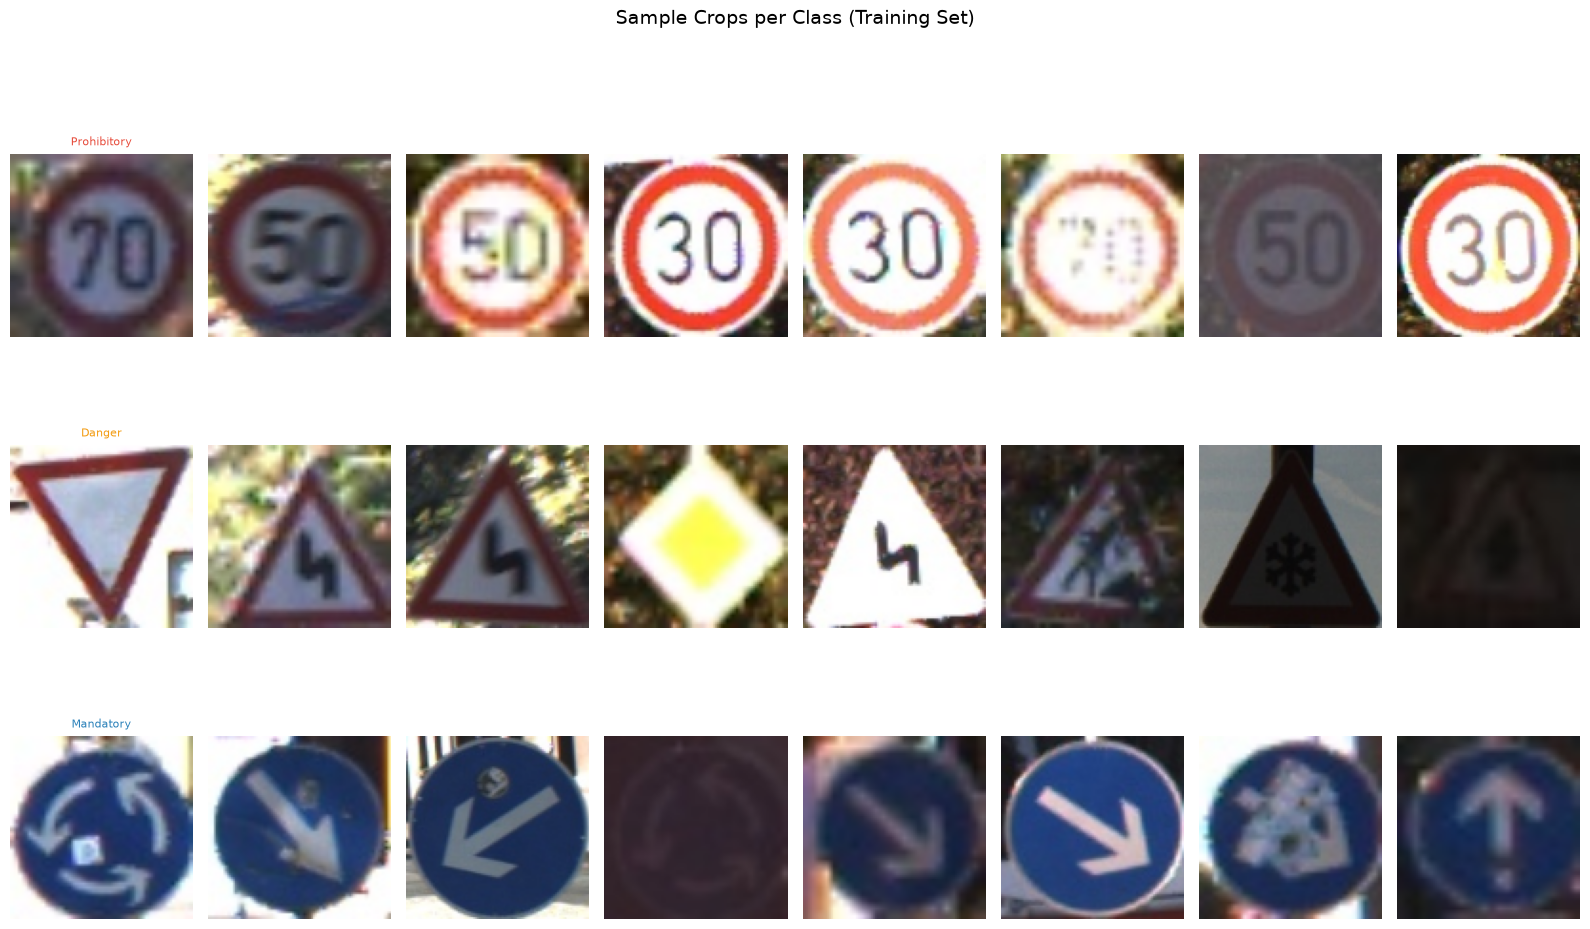

Saved → E:\traffic-sign-detection\results\figures\sample_grid_per_class.png


In [20]:
def show_sample_grid(split_dir: Path, class_id: int, n_samples: int = 8):
    """Display a grid of cropped sign regions for one class."""
    lbl_dir = split_dir / 'labels'
    img_dir = split_dir / 'images'
    crops = []

    for lbl_path in list(lbl_dir.glob('*.txt')):
        if len(crops) >= n_samples:
            break
        img_path = img_dir / (lbl_path.stem + '.jpg')
        img = cv2.imread(str(img_path))
        if img is None:
            continue
        h, w = img.shape[:2]
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) == 5 and int(parts[0]) == class_id:
                    xc, yc, bw, bh = map(float, parts[1:])
                    x1 = max(0, int((xc - bw/2) * w))
                    y1 = max(0, int((yc - bh/2) * h))
                    x2 = min(w, int((xc + bw/2) * w))
                    y2 = min(h, int((yc + bh/2) * h))
                    crop = img[y1:y2, x1:x2]
                    if crop.size > 0:
                        crop = cv2.resize(crop, (96, 96))
                        crops.append(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
                        if len(crops) >= n_samples:
                            break
    return crops

fig, big_axes = plt.subplots(3, 1, figsize=(16, 10))
fig.suptitle('Sample Crops per Class (Training Set)', fontsize=14, y=1.01)

for row, (cls_id, cls_name) in enumerate(CLASS_NAMES.items()):
    crops = show_sample_grid(TRAIN_DIR, cls_id, n_samples=8)
    # Create a horizontal strip
    strip_axes = [fig.add_subplot(3, 8, row*8 + col + 1) for col in range(min(8, len(crops)))]
    big_axes[row].set_visible(False)
    for i, ax in enumerate(strip_axes):
        if i < len(crops):
            ax.imshow(crops[i])
            ax.set_title(cls_name if i == 0 else '', fontsize=8, color=CLASS_COLOURS[cls_id])
        ax.axis('off')

plt.tight_layout()
out = PROJECT_ROOT / 'results' / 'figures' / 'sample_grid_per_class.png'
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {out}')

## 5. Full Scene Sample (with Bounding Boxes Drawn)

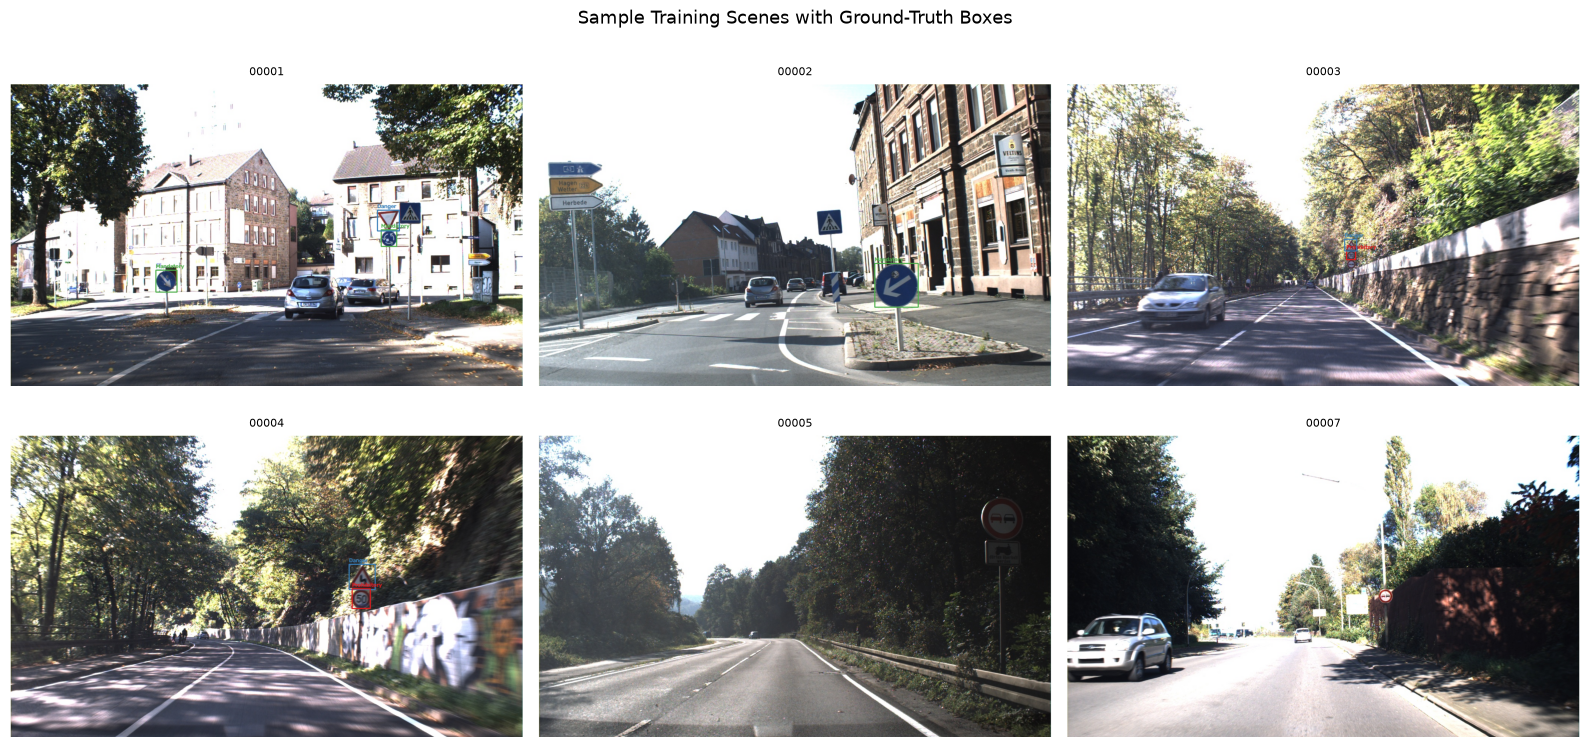

Saved → E:\traffic-sign-detection\results\figures\sample_scenes_with_boxes.png


In [21]:
def draw_boxes_on_image(img_path: Path, lbl_path: Path) -> np.ndarray:
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]
    with open(lbl_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cls_id = int(parts[0])
                xc, yc, bw, bh = map(float, parts[1:])
                x1 = int((xc - bw/2) * w)
                y1 = int((yc - bh/2) * h)
                x2 = int((xc + bw/2) * w)
                y2 = int((yc + bh/2) * h)
                colour = tuple(int(c*255) for c in plt.cm.Set1(cls_id)[:3])
                cv2.rectangle(img, (x1,y1), (x2,y2), colour, 2)
                cv2.putText(img, CLASS_NAMES.get(cls_id,'?'), (x1,y1-5),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.5, colour, 2)
    return img

# Show up to 6 annotated training images
img_dir = TRAIN_DIR / 'images'
lbl_dir = TRAIN_DIR / 'labels'
pairs = [(p, lbl_dir / (p.stem + '.txt'))
         for p in sorted(img_dir.glob('*.jpg'))[:6]
         if (lbl_dir / (p.stem + '.txt')).exists()]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle('Sample Training Scenes with Ground-Truth Boxes', fontsize=13)
for ax, (img_p, lbl_p) in zip(axes.flatten(), pairs):
    annotated = draw_boxes_on_image(img_p, lbl_p)
    if annotated is not None:
        ax.imshow(annotated)
        ax.set_title(img_p.stem, fontsize=8)
    ax.axis('off')
plt.tight_layout()
out = PROJECT_ROOT / 'results' / 'figures' / 'sample_scenes_with_boxes.png'
plt.savefig(out, dpi=150)
plt.show()
print(f'Saved → {out}')

## 6. EDA Summary & Observations

Fill in after running all cells above:

| Observation | Detail |
|---|---|
| Class imbalance | _(e.g. Prohibitory >> Mandatory)_ |
| Smallest signs | _(e.g. min bbox ~16×16 px)_ |
| Dominant split | _(train vs test ratio)_ |
| Potential bias | _(e.g. mostly German signs)_ |

**Action items based on EDA:**
- [ ] Use class-weighted loss if imbalance is severe
- [ ] Train at higher `imgsz` (800+) if many small signs
- [ ] Apply augmentation to address low-count classes